In [1]:
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)

C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

NetKet version: 3.21.1.dev13+gbf43effcb


In [2]:
L = 19  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))

chain nodes = 19 , chain edges = 18
n_orbitals = 20
fixed particles (N_up, N_dn) = (10, 10)


In [3]:
U = 4.0

# Wilson chain 参数
D = 1.0
Lambda = 2.0
V = 0.15 * D

# t_j, j = 1, 2, ..., L-1（对应哈密顿量里的 ti[i-1]）
j = np.arange(0, L-1, dtype=float)
ti = (
    ((1.0 + Lambda**-1.0) * (1.0 - Lambda**(-j - 1.0)))
    / (
        2.0
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 1.0))
        * np.sqrt(1.0 - Lambda**(-2.0 * j - 3.0))
    )
    * Lambda**(-j / 2.0)
    * D
)

In [4]:
H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H

FermionOperator2ndJax(hilbert=SpinOrbitalFermions(n_orbitals=20, s=1/2, n_fermions=20, n_fermions_per_spin=(10, 10)), n_operators=80, dtype=float64)

In [5]:
print('max_conn_size =', H.max_conn_size)
print('ti length =', len(ti), '(expected L-1 =', L - 1, ')')

D:\Seafile\PHD\NQS\NetKet\netket\netket\operator\_fermion2nd\jax.py:557: UserWarning: 
Consider using `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd` to reduce the number of connected elements and
considerably reduce the computational cost.
You can convert this operator by calling `netket.experimental.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd`.

  super()._setup(self)


max_conn_size = 77
ti length = 18 (expected L-1 = 18 )


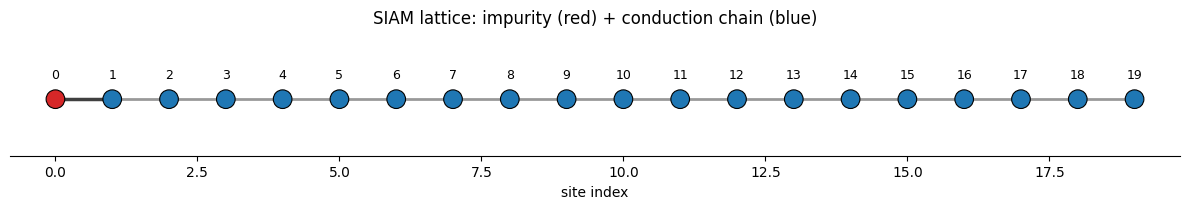

In [6]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 20 19
seeds: (11, 101, 22, 202, 33, 303)


In [15]:
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

model_slater = LogSlaterDeterminant(hi)
sa_slater = nk.sampler.MetropolisFermionHop(
    hi, graph=graph_sampler, spin_symmetric=True
 )
vstate_slater = nk.vqs.MCState(
    sa_slater,
    model_slater,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_SLATER,
    sampler_seed=SEED_SAMPLER_SLATER,
 )

op_slater = nk.optimizer.Sgd(learning_rate=0.05)
gs_slater = nk.driver.VMC_SR(
    H, op_slater, variational_state=vstate_slater, diag_shift=0.05, mode="real"
 )

slater_log = nk.logging.RuntimeLog()
gs_slater.run(n_iter=200, out=slater_log)

E_slater = vstate_slater.expect(H)
print(f"Slater optimized energy: {E_slater}")

Automatic SR implementation choice:  QGT


100%|██████████| 200/200 [03:13<00:00,  1.03it/s, Energy=-3.8968-0.0000j ± 0.0013 [σ²=3.8e-03, R̂=1.014]]


Slater optimized energy: -3.8945+0.0000j ± 0.0018 [σ²=8.1e-03, R̂=1.010]


In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(1, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

 [NJ] Params: 443
Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [06:03<00:00,  1.21s/it, Energy=-3.18699+0.00000j ± 0.00065 [σ²=8.2e-04, R̂=1.008]]


TypeError: unsupported operand type(s) for -: 'jaxlib._jax.ArrayImpl' and 'NoneType'

>>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)


C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


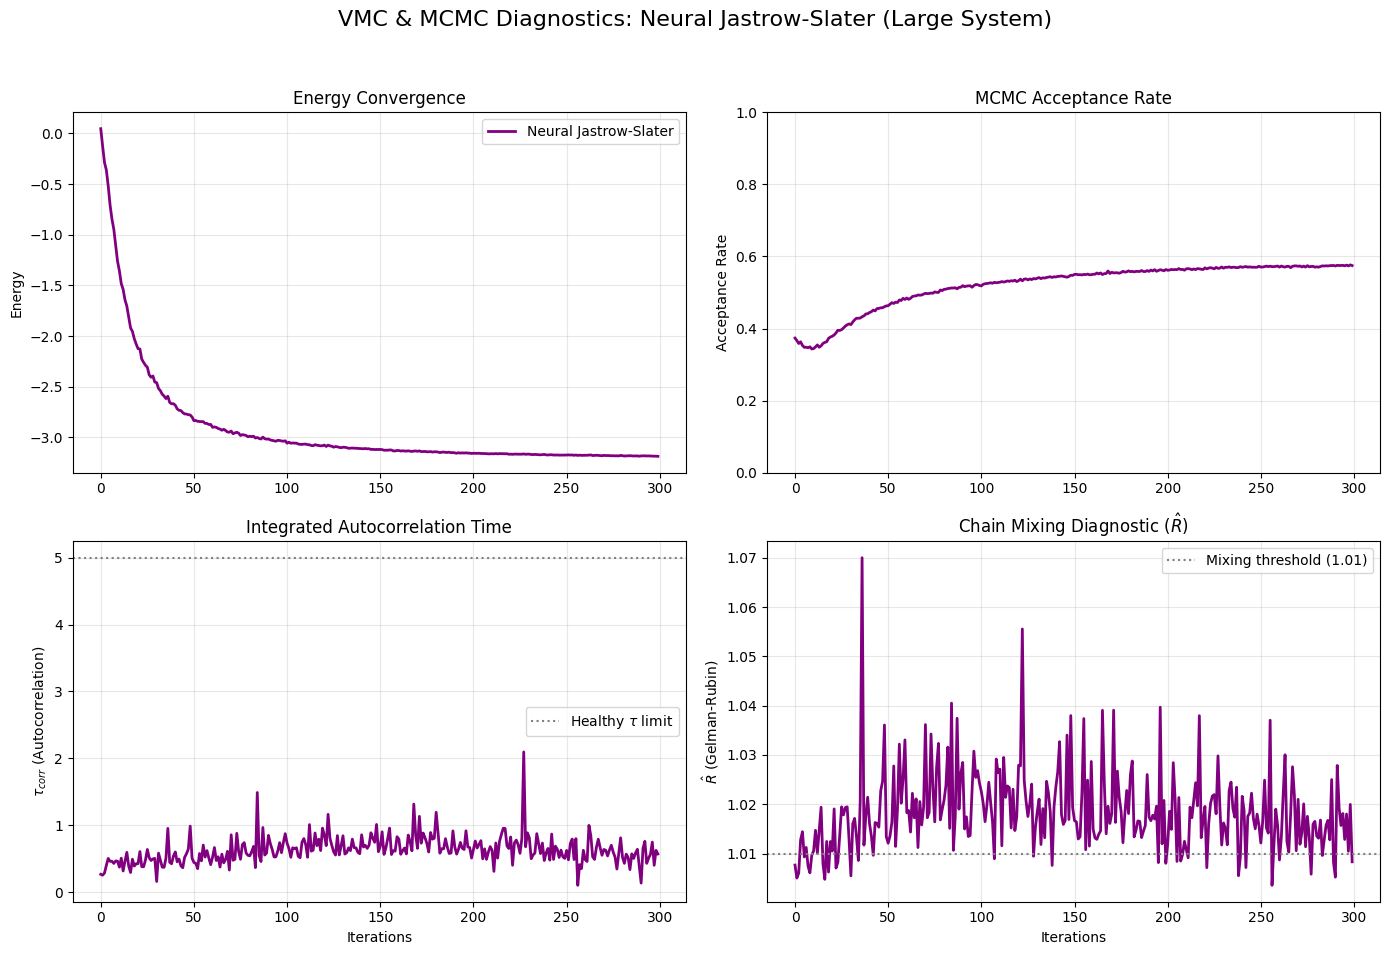

In [11]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (鲁棒性语法)
# ==============================================================================
# 提取迭代步数
iters = nj_log.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in nj_log.data else 'acceptance'

# 提取 Neural Jastrow-Slater 的数据
E_nj_vals = nj_log.data['Energy']['Mean']
acc_nj_vals = nj_log.data[acc_key]['value']
tau_nj_vals = nj_log.data['Energy']['TauCorr']
rhat_nj_vals = nj_log.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Neural Jastrow-Slater (Large System)', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_nj_vals, label='Neural Jastrow-Slater', color='purple', linewidth=2)
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_nj_vals, color='purple', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_nj_vals, color='purple', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_nj_vals, color='purple', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn

class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32  # 建议给个默认数值，防止外部 N 未定义报错

    @nn.compact
    def __call__(self, n):
        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=float
        )(n)

        x = n.astype(jnp.float32)
        j = nn.Dense(self.hidden_units)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1)(j).squeeze(-1)
        return log_slater + j

model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(8, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
 )
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

op_nj = nk.optimizer.Sgd(learning_rate=0.05)
gs_nj = nk.driver.VMC_SR(
    H, op_nj, variational_state=vstate_nj, diag_shift=0.05, mode="real"
 )

nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

# 只评估最终的变分期望能量，彻底告别 ED 相对误差
E_nj = vstate_nj.expect(H)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

 [NJ] Params: 737
Automatic SR implementation choice:  QGT


100%|██████████| 300/300 [05:40<00:00,  1.13s/it, Energy=-3.18494-0.00000j ± 0.00073 [σ²=1.0e-03, R̂=1.023]]


Neural Jastrow-Slater optimized energy: -3.18263-0.00000j ± 0.00094 [σ²=1.6e-03, R̂=1.019]


>>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)


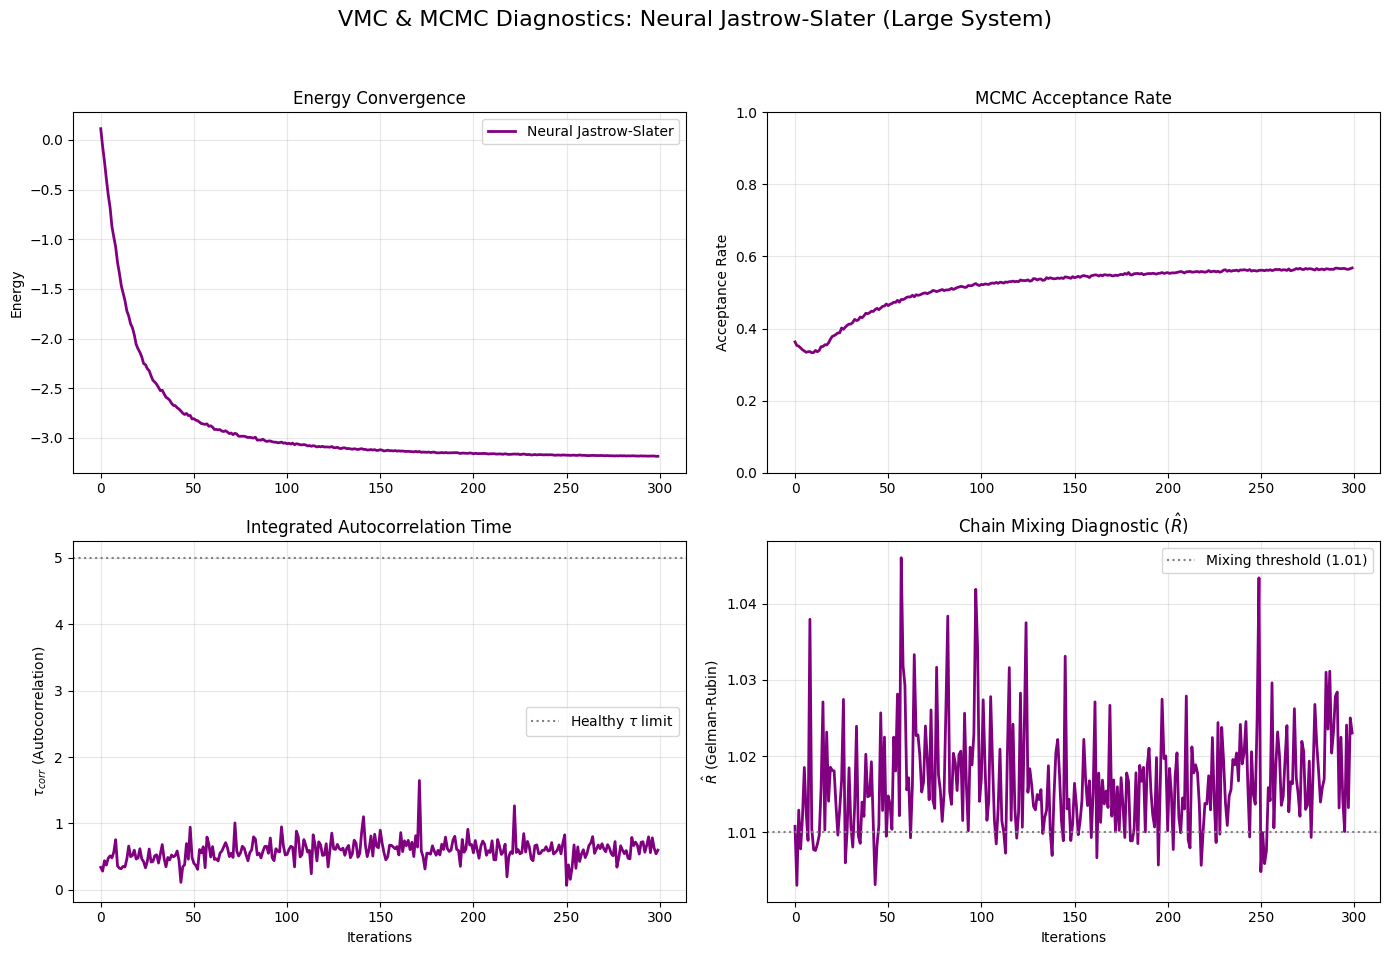

In [13]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (鲁棒性语法)
# ==============================================================================
# 提取迭代步数
iters = nj_log.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in nj_log.data else 'acceptance'

# 提取 Neural Jastrow-Slater 的数据
E_nj_vals = nj_log.data['Energy']['Mean']
acc_nj_vals = nj_log.data[acc_key]['value']
tau_nj_vals = nj_log.data['Energy']['TauCorr']
rhat_nj_vals = nj_log.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Neural Jastrow-Slater (Large System)', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_nj_vals, label='Neural Jastrow-Slater', color='purple', linewidth=2)
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_nj_vals, color='purple', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_nj_vals, color='purple', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_nj_vals, color='purple', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn
import optax
import jax.scipy.sparse.linalg

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz (修正 dtype)
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 强制指定 dtype 为 float64
        dtype = jnp.float64

        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=dtype
        )(n)

        # 确保输入转换成 float64
        x = n.astype(dtype)
        # 显式告诉 Dense 层使用 float64 初始化权重
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        return log_slater + j

# ==============================================================================
# 2. 初始化模型、采样器与变分态
# ==============================================================================
model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(8, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**14,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
)
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

# ==============================================================================
# 3. 外层优化器升级：Optax Adam + 余弦退火学习率
# ==============================================================================
lr_schedule = optax.cosine_decay_schedule(
    init_value=0.05, 
    decay_steps=300, 
    alpha=0.01  
)
op_nj = optax.adam(learning_rate=lr_schedule)

# ==============================================================================
# 4. 内层 SR 求解器升级：共轭梯度法 (CG) 预条件器
# ==============================================================================
sr_preconditioner = nk.optimizer.SR(
    diag_shift=0.01, 
    solver=jax.scipy.sparse.linalg.cg  # 继续使用原生 cg
)

gs_nj = nk.driver.VMC(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    preconditioner=sr_preconditioner
)

# =============================================================================
# 5. 运行优化与日志记录
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

# ==============================================================================
# 6. 评估最终变分能量
# ==============================================================================
E_nj = vstate_nj.expect(H)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

 [NJ] Params: 737


100%|██████████| 300/300 [38:04<00:00,  7.61s/it, Energy=-3.238366-0.000000j ± 0.000059 [σ²=5.4e-05, R̂=1.001]]


Neural Jastrow-Slater optimized energy: -3.238293+0.000000j ± 0.000073 [σ²=8.2e-05, R̂=1.001]


>>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)


C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\10783\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


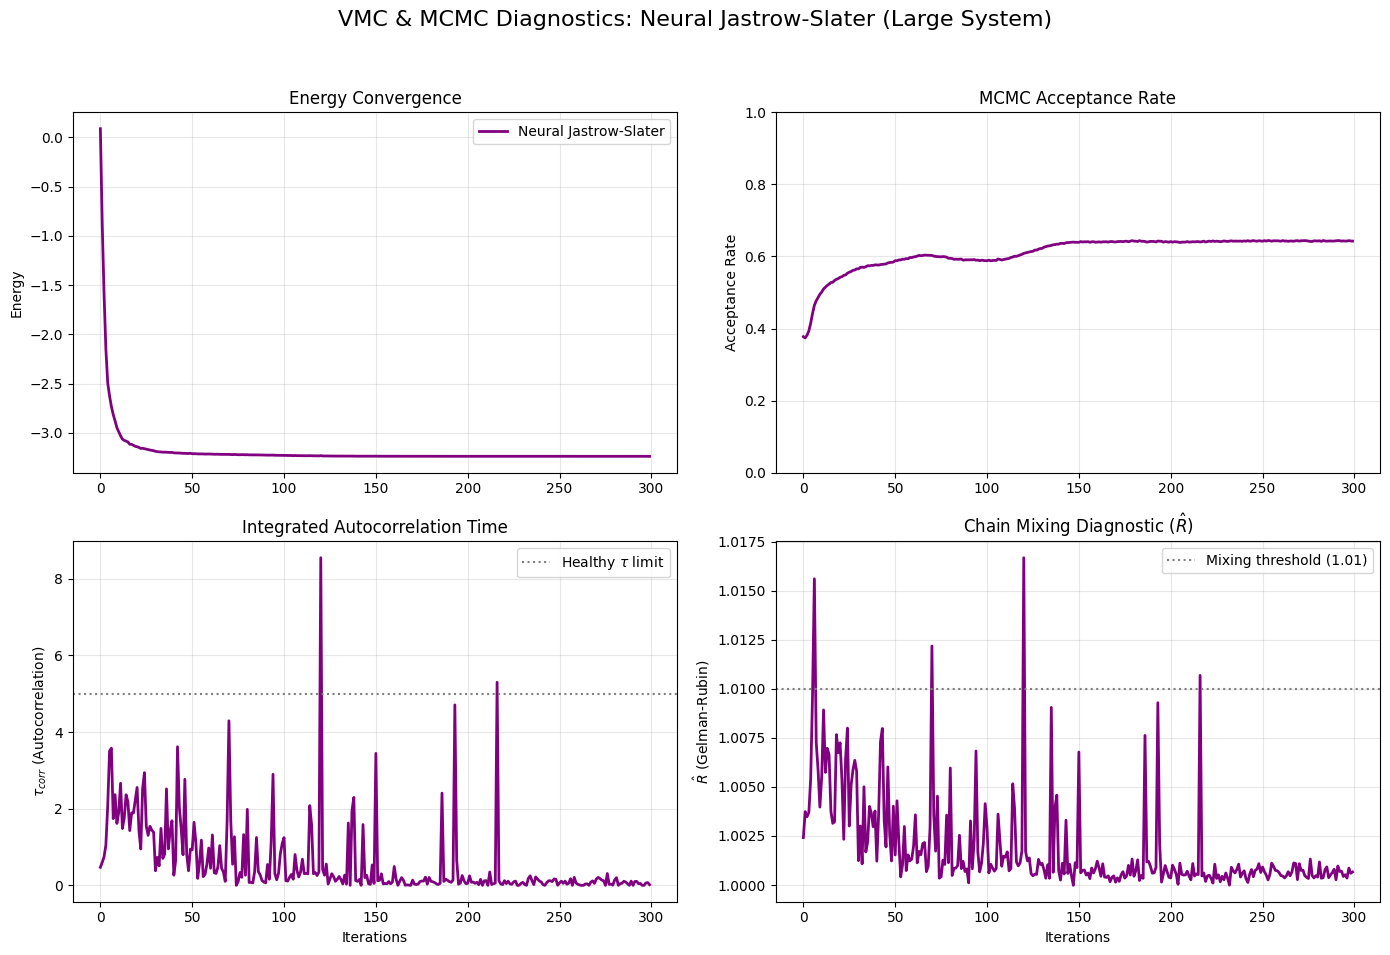

In [19]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 3] 绘制 MCMC 统计动力学全景诊断图 (大体系无 ED 版本)")
print("=" * 70)

# ==============================================================================
# 1. 从 RuntimeLog 中提取数据 (鲁棒性语法)
# ==============================================================================
# 提取迭代步数
iters = nj_log.data['Energy'].iters

# 自动兼容 NetKet 不同版本的接受率键名 (大小写容错)
acc_key = 'Acceptance' if 'Acceptance' in nj_log.data else 'acceptance'

# 提取 Neural Jastrow-Slater 的数据
E_nj_vals = nj_log.data['Energy']['Mean']
acc_nj_vals = nj_log.data[acc_key]['value']
tau_nj_vals = nj_log.data['Energy']['TauCorr']
rhat_nj_vals = nj_log.data['Energy']['R_hat']

# ==============================================================================
# 2. 绘制 2x2 面板
# ==============================================================================
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('VMC & MCMC Diagnostics: Neural Jastrow-Slater (Large System)', fontsize=16)

# --- Subplot 1: Energy Convergence ---
axs[0, 0].plot(iters, E_nj_vals, label='Neural Jastrow-Slater', color='purple', linewidth=2)
axs[0, 0].set_ylabel('Energy')
axs[0, 0].set_title('Energy Convergence')
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.3)

# --- Subplot 2: Acceptance Rate ---
axs[0, 1].plot(iters, acc_nj_vals, color='purple', linewidth=2)
axs[0, 1].set_ylabel('Acceptance Rate')
axs[0, 1].set_title('MCMC Acceptance Rate')
axs[0, 1].set_ylim(0, 1.0)
axs[0, 1].grid(alpha=0.3)

# --- Subplot 3: Autocorrelation Time (Tau) ---
axs[1, 0].plot(iters, tau_nj_vals, color='purple', linewidth=2)
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('$\\tau_{corr}$ (Autocorrelation)')
axs[1, 0].set_title('Integrated Autocorrelation Time')
# 画一条 tau = 5 的健康基准线
axs[1, 0].axhline(y=5, color='gray', linestyle=':', label='Healthy $\\tau$ limit') 
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.3)

# --- Subplot 4: Gelman-Rubin R_hat ---
axs[1, 1].plot(iters, rhat_nj_vals, color='purple', linewidth=2)
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('$\\hat{R}$ (Gelman-Rubin)')
axs[1, 1].set_title('Chain Mixing Diagnostic ($\\hat{R}$)')
# 画一条 R_hat = 1.01 的健康基准线
axs[1, 1].axhline(y=1.01, color='gray', linestyle=':', label='Mixing threshold (1.01)')
axs[1, 1].legend()
axs[1, 1].grid(alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn
import optax
import jax.scipy.sparse.linalg

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz (修正 dtype)
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 强制指定 dtype 为 float64
        dtype = jnp.float64

        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=dtype
        )(n)

        # 确保输入转换成 float64
        x = n.astype(dtype)
        # 显式告诉 Dense 层使用 float64 初始化权重
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        return log_slater + j

# ==============================================================================
# 2. 初始化模型、采样器与变分态
# ==============================================================================
model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(1, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
)
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

# ==============================================================================
# 3. 外层优化器升级：Optax Adam + 余弦退火学习率
# ==============================================================================
lr_schedule = optax.cosine_decay_schedule(
    init_value=0.05, 
    decay_steps=300, 
    alpha=0.01  
)
op_nj = optax.adam(learning_rate=lr_schedule)

# ==============================================================================
# 4. 内层 SR 求解器升级：共轭梯度法 (CG) 预条件器
# ==============================================================================
sr_preconditioner = nk.optimizer.SR(
    diag_shift=0.01, 
    solver=jax.scipy.sparse.linalg.cg  # 继续使用原生 cg
)

gs_nj = nk.driver.VMC(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    preconditioner=sr_preconditioner
)

# =============================================================================
# 5. 运行优化与日志记录
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=200, out=nj_log)

# ==============================================================================
# 6. 评估最终变分能量
# ==============================================================================
E_nj = vstate_nj.expect(H)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

 [NJ] Params: 443


100%|██████████| 200/200 [14:54<00:00,  4.47s/it, Energy=-3.23507-0.00000j ± 0.00050 [σ²=9.7e-04, R̂=1.004]]


Neural Jastrow-Slater optimized energy: -3.23514-0.00000j ± 0.00019 [σ²=8.1e-05, R̂=1.024]


In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import flax.linen as nn
import optax
import jax.scipy.sparse.linalg

# ==============================================================================
# 1. 定义 Neural Jastrow-Slater Ansatz (修正 dtype)
# ==============================================================================
class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 强制指定 dtype 为 float64
        dtype = jnp.float64

        log_slater = nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=False, param_dtype=dtype
        )(n)

        # 确保输入转换成 float64
        x = n.astype(dtype)
        # 显式告诉 Dense 层使用 float64 初始化权重
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        return log_slater + j

# ==============================================================================
# 2. 初始化模型、采样器与变分态
# ==============================================================================
model_nj = LogNeuralJastrowSlater(hi, hidden_units=min(40, 2 * n_orbitals))
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**14,
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,
    sampler_seed=SEED_SAMPLER_NJ,
)
nj_p = vstate_nj.n_parameters
print(f" [NJ] Params: {nj_p}")

# ==============================================================================
# 3. 外层优化器升级：Optax Adam + 余弦退火学习率
# ==============================================================================
lr_schedule = optax.cosine_decay_schedule(
    init_value=0.05, 
    decay_steps=300, 
    alpha=0.01  
)
op_nj = optax.adam(learning_rate=lr_schedule)

# ==============================================================================
# 4. 内层 SR 求解器升级：共轭梯度法 (CG) 预条件器
# ==============================================================================
sr_preconditioner = nk.optimizer.SR(
    diag_shift=0.01, 
    solver=jax.scipy.sparse.linalg.cg  # 继续使用原生 cg
)

gs_nj = nk.driver.VMC(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    preconditioner=sr_preconditioner
)

# =============================================================================
# 5. 运行优化与日志记录
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
gs_nj.run(n_iter=300, out=nj_log)

# ==============================================================================
# 6. 评估最终变分能量
# ==============================================================================
E_nj = vstate_nj.expect(H)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

 [NJ] Params: 2081


100%|██████████| 300/300 [1:19:49<00:00, 15.97s/it, Energy=-3.236045+0.000000j ± 0.000055 [σ²=3.0e-05, R̂=1.001]]


Neural Jastrow-Slater optimized energy: -3.236174-0.000000j ± 0.000043 [σ²=1.9e-05, R̂=1.001]


>>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)
提取到的权重矩阵形状: (40, 1) (轨道数: 40, 隐藏节点数: 1)


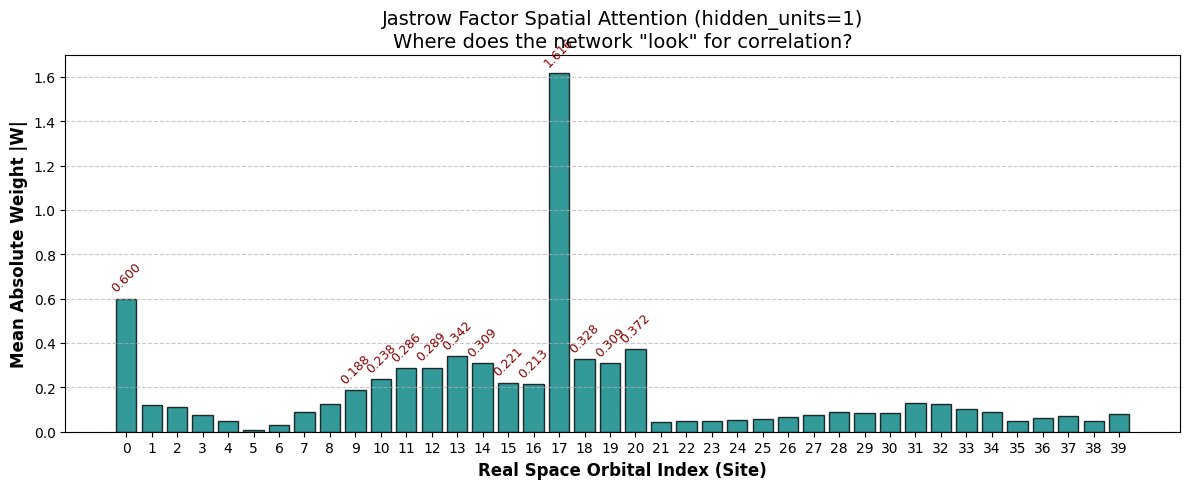

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)")
print("=" * 70)

# ==============================================================================
# 1. 提取变分态的参数
# ==============================================================================
params = vstate_nj.parameters

# Flax 默认把第一个 nn.Dense 命名为 'Dense_0'
# 这里的 kernel 矩阵形状是 (n_orbitals, hidden_units)
try:
    w_kernel = np.array(params['Dense_0']['kernel'])
except KeyError:
    # 兼容性备用方案：如果网络结构被稍微包裹过，尝试模糊获取
    layer_keys = list(params.keys())
    w_kernel = np.array(params[layer_keys[0]]['kernel'])

n_orb, h_units = w_kernel.shape
print(f"提取到的权重矩阵形状: {w_kernel.shape} (轨道数: {n_orb}, 隐藏节点数: {h_units})")

# ==============================================================================
# 2. 计算空间注意力 (Spatial Attention)
# ==============================================================================
# 计算每个实空间格点连接到所有隐藏节点的“平均绝对权重”。
# 值越大，说明 Jastrow 因子越“死盯着”这个格点来施加多体关联惩罚。
site_importance = np.mean(np.abs(w_kernel), axis=1)

# ==============================================================================
# 3. 绘制实空间权重分布图
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

# 绘制柱状图
bars = ax.bar(range(n_orb), site_importance, color='teal', alpha=0.8, edgecolor='black')

ax.set_xlabel('Real Space Orbital Index (Site)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Weight |W|', fontsize=12, fontweight='bold')
ax.set_title(f'Jastrow Factor Spatial Attention (hidden_units={h_units})\nWhere does the network "look" for correlation?', fontsize=14)
ax.set_xticks(range(n_orb))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在显著的柱子上标注具体数值 (过滤掉接近 0 的废弃轨道)
threshold = np.max(site_importance) * 0.1  # 只标注最大权重 10% 以上的柱子
for idx, bar in enumerate(bars):
    height = bar.get_height()
    if height > threshold:
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移 3 个像素
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=45, color='darkred')

plt.tight_layout()
plt.show()

>>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)
提取到的权重矩阵形状: (40, 40) (轨道数: 40, 隐藏节点数: 40)


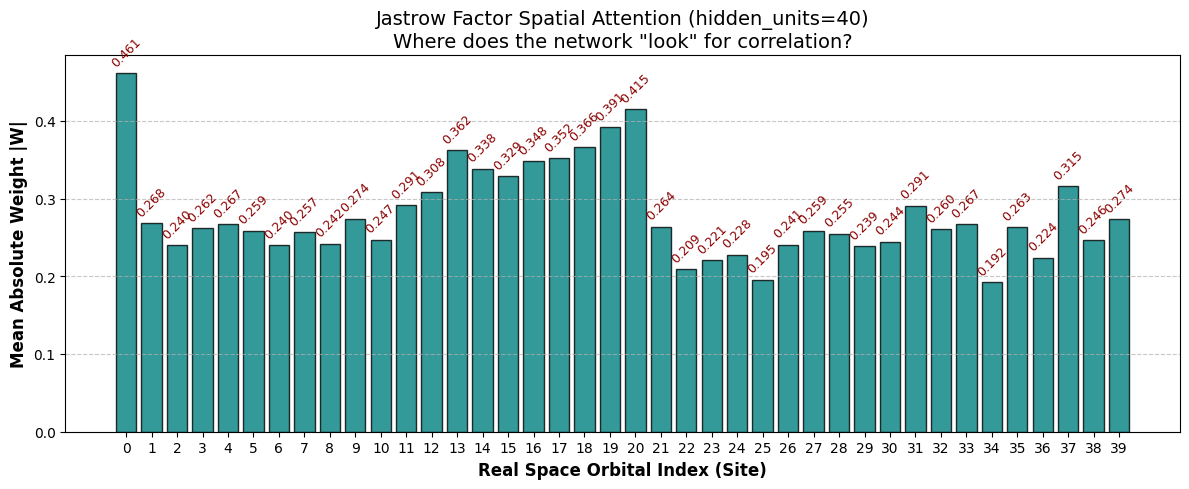

In [24]:
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print(">>> [Cell 4] 可视化 Jastrow 因子的实空间轨道权重 (Spatial Attention)")
print("=" * 70)

# ==============================================================================
# 1. 提取变分态的参数
# ==============================================================================
params = vstate_nj.parameters

# Flax 默认把第一个 nn.Dense 命名为 'Dense_0'
# 这里的 kernel 矩阵形状是 (n_orbitals, hidden_units)
try:
    w_kernel = np.array(params['Dense_0']['kernel'])
except KeyError:
    # 兼容性备用方案：如果网络结构被稍微包裹过，尝试模糊获取
    layer_keys = list(params.keys())
    w_kernel = np.array(params[layer_keys[0]]['kernel'])

n_orb, h_units = w_kernel.shape
print(f"提取到的权重矩阵形状: {w_kernel.shape} (轨道数: {n_orb}, 隐藏节点数: {h_units})")

# ==============================================================================
# 2. 计算空间注意力 (Spatial Attention)
# ==============================================================================
# 计算每个实空间格点连接到所有隐藏节点的“平均绝对权重”。
# 值越大，说明 Jastrow 因子越“死盯着”这个格点来施加多体关联惩罚。
site_importance = np.mean(np.abs(w_kernel), axis=1)

# ==============================================================================
# 3. 绘制实空间权重分布图
# ==============================================================================
fig, ax = plt.subplots(figsize=(12, 5))

# 绘制柱状图
bars = ax.bar(range(n_orb), site_importance, color='teal', alpha=0.8, edgecolor='black')

ax.set_xlabel('Real Space Orbital Index (Site)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Absolute Weight |W|', fontsize=12, fontweight='bold')
ax.set_title(f'Jastrow Factor Spatial Attention (hidden_units={h_units})\nWhere does the network "look" for correlation?', fontsize=14)
ax.set_xticks(range(n_orb))
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 在显著的柱子上标注具体数值 (过滤掉接近 0 的废弃轨道)
threshold = np.max(site_importance) * 0.1  # 只标注最大权重 10% 以上的柱子
for idx, bar in enumerate(bars):
    height = bar.get_height()
    if height > threshold:
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 垂直偏移 3 个像素
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=45, color='darkred')

plt.tight_layout()
plt.show()

In [9]:
class LogNeuralBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = N

    @nn.compact
    def __call__(self, n):
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # 限制型 HF 基轨道（所有自旋扇区共享）
        M = self.param(
            "M",
            nn.initializers.lecun_normal(),
            (n_orb, nfs),
            float,
        )

        # Backflow 网络：输出 (n_spin, n_orb, nfs)
        x = n.astype(jnp.float32)
        F = nn.Dense(self.hidden_units)(x)
        F = jax.nn.tanh(F)
        F = nn.Dense(n_spin * n_orb * nfs)(F)
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        return log_bf(n, F)

model_bf = LogNeuralBackflow(hi, hidden_units=max(32, 2 * n_orbitals))
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)
vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**12,
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,
    sampler_seed=SEED_SAMPLER_BF,
 )

op_bf = nk.optimizer.Sgd(learning_rate=0.05)
gs_bf = nk.driver.VMC_SR(
    H, op_bf, variational_state=vstate_bf, diag_shift=0.05, mode="real"
 )

bf_log = nk.logging.RuntimeLog()
gs_bf.run(n_iter=300, out=bf_log)

E_bf = vstate_bf.expect(H)
err_bf = abs((E_bf.mean - E_gs) / E_gs)
print(f"Neural Backflow optimized energy: {E_bf}")
print(f"Neural Backflow relative error  : {err_bf}")

Automatic SR implementation choice:  NTK


 69%|██████▊   | 206/300 [12:52<05:52,  3.75s/it, Energy=-3.0746+0.0000j ± 0.0033 [σ²=2.2e-02, R̂=1.010]]


KeyboardInterrupt: 

In [8]:
import flax.linen as nn
import jax.numpy as jnp
import jax
from functools import partial
import netket as nk

class LogNeuralJastrowBackflow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 64  # 稍微增大隐藏层

    @nn.compact
    def __call__(self, n):
        # 强制使用高精度，防止行列式数值不稳定
        dtype = jnp.float64
        
        n_orb = self.hilbert.n_orbitals
        n_spin = self.hilbert.n_spin_subsectors
        nfs = self.hilbert.n_fermions_per_spin[0]

        # =========================================================
        # 1. 基础 Slater 轨道矩阵 (M)
        # =========================================================
        M = self.param(
            "M",
            nn.initializers.normal(stddev=0.1), # 给定一个较小的初始扰动
            (n_orb, nfs),
            dtype,
        )

        x = n.astype(dtype)

        # =========================================================
        # 2. Backflow 神经网络 (F) - 负责动态扭曲波函数节点面
        # =========================================================
        # 使用稍微深一点的网络，并换用 SiLU 激活函数以获得更好的梯度
        h_bf = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        h_bf = jax.nn.silu(h_bf)
        h_bf = nn.Dense(self.hidden_units, param_dtype=dtype)(h_bf)
        h_bf = jax.nn.silu(h_bf)
        
        # 【关键技巧】：最后一层权重初始化为 0！
        # 这样网络初始状态下的 F 完全为 0，退化为标准的 Slater 行列式
        F = nn.Dense(
            n_spin * n_orb * nfs, 
            param_dtype=dtype,
            kernel_init=nn.initializers.zeros_init(),
            bias_init=nn.initializers.zeros_init()
        )(h_bf)
        
        # 保持 batch 维度不变，重塑形状
        F = F.reshape(F.shape[:-1] + (n_spin, n_orb, nfs))

        # =========================================================
        # 3. Jastrow 因子 (J) - 负责处理局域强排斥 (Hubbard U)
        # =========================================================
        h_J = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        h_J = jax.nn.tanh(h_J)
        J = nn.Dense(1, param_dtype=dtype)(h_J).squeeze(-1)

        # =========================================================
        # 4. 组装并计算 Log 振幅
        # =========================================================
        @partial(jnp.vectorize, signature="(m),(s,o,f)->()")
        def log_bf(n_one, F_one):
            R = n_one.nonzero(size=self.hilbert.n_fermions)[0]
            log_det_sum = 0.0 + 0.0j
            i_start = 0

            for i, nf_i in enumerate(self.hilbert.n_fermions_per_spin):
                if nf_i == 0:
                    continue
                R_i = R[i_start : i_start + nf_i] - i * n_orb
                
                # 行列式内部的轨道基底被 Backflow 动态修正: M + F(n)
                A_i = (M + F_one[i])[R_i]
                log_det_sum = log_det_sum + nk.jax.logdet_cmplx(A_i)
                i_start += nf_i

            return log_det_sum

        # 最终输出 = Backflow行列式 + Jastrow振幅修正
        return log_bf(n, F) + J


In [ ]:
import jax
import jax.numpy as jnp
import netket as nk
import optax
import jax.scipy.sparse.linalg

print("=" * 70)
print(">>> [Backflow] 完美修正版：VMC_SR (自动 NTK) + Adam")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型、采样器与变分态 
# ==============================================================================
# 使用 SJB 架构 (LogNeuralJastrowBackflow)，hidden_units 设为 32 控制参数量
model_bf = LogNeuralJastrowBackflow(hi, hidden_units=32)
sa_bf = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

vstate_bf = nk.vqs.MCState(
    sa_bf,
    model_bf,
    n_samples=2**12,          # 【优化】：从 16384 降到 8192，大幅加速单步计算，防内存爆炸
    n_discard_per_chain=16,
    seed=SEED_MODEL_BF,       # 确保全局已定义
    sampler_seed=SEED_SAMPLER_BF,
)

bf_p = vstate_bf.n_parameters
print(f" [Backflow] Total Params: {bf_p}")

# ==============================================================================
# 2. 外层优化器：Optax Adam + 余弦退火
# ==============================================================================
lr_schedule_bf = optax.cosine_decay_schedule(
    init_value=0.02, 
    decay_steps=300, 
    alpha=0.01  
)
op_bf = optax.adam(
    learning_rate=lr_schedule_bf,
    b1=0.8,         # <--- 从默认的 0.9 降下来
    b2=0.999,       # <--- 保持极高的方差平滑
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR
# ==============================================================================
# 【核心修正 1】：op_bf 作为位置参数传入，不使用 optimizer=op_bf
# 【核心修正 2】：删除 solver=cg，让 NetKet 使用默认的高效 NTK 求解器
gs_bf = nk.driver.VMC_SR(
    H,                            # 位置参数 1: 哈密顿量
    op_bf,                        # 位置参数 2: 优化器
    variational_state=vstate_bf,  # 变分态
    diag_shift=0.02,             # 阻尼正则化参数
    mode="real"
)

# ==============================================================================
# 4. 运行优化与日志
# ==============================================================================
bf_log = nk.logging.RuntimeLog()
print("开始运行 Backflow 优化 (这会比普通 Jastrow 慢，但更加精确)...")
gs_bf.run(n_iter=300, out=bf_log)

# ==============================================================================
# 5. 评估结果
# ==============================================================================
E_bf = vstate_bf.expect(H)
print("-" * 70)
print(f"Neural Backflow optimized energy: {E_bf}")

>>> [Backflow] 完美修正版：VMC_SR (自动 NTK) + Adam
 [Backflow] Total Params: 17113
Automatic SR implementation choice:  NTK
开始运行 Backflow 优化 (这会比普通 Jastrow 慢，但更加精确)...


100%|██████████| 300/300 [24:20<00:00,  4.87s/it, Energy=-3.99511-0.00000j ± 0.00012 [σ²=5.4e-05, R̂=1.004]]   


----------------------------------------------------------------------
Neural Backflow optimized energy: -3.994966+0.000000j ± 0.000052 [σ²=9.0e-06, R̂=1.005]


In [9]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk

print("=" * 70)
print(">>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设")
print("=" * 70)

class LogNeuralJastrowSlater(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    hidden_units: int = 32

    @nn.compact
    def __call__(self, n):
        # 1. 强制全局使用 float64，保证行列式求对数的数值稳定性
        dtype = jnp.float64

        # 2. Slater 行列式 (物理层：处理节点面和正负号)
        # 尽管 param_dtype 是实数，NetKet 底层遇到负行列式会自动安全提升为 complex128
        log_slater = nk.models.Slater2nd(
            self.hilbert, 
            generalized=False, 
            restricted=False, 
            param_dtype=dtype
        )(n)

        # 3. Neural Jastrow 因子 (关联层：处理 Hubbard U 和振幅压制)
        x = n.astype(dtype)
        # 第一层：提取轨道间的协同模式
        j = nn.Dense(self.hidden_units, param_dtype=dtype)(x)
        j = jax.nn.tanh(j)
        # 第二层：压缩为标量能量惩罚/奖励分值
        j = nn.Dense(1, param_dtype=dtype)(j).squeeze(-1)
        
        # 4. 终极组合：实数关联振幅 + 复数节点相位
        return log_slater + j

print("拟设类 LogNeuralJastrowSlater 编译完成！")

>>> [Cell 1] 定义高精度 LogNeuralJastrowSlater 拟设
拟设类 LogNeuralJastrowSlater 编译完成！


In [10]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=1)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================
gs_nj = nk.driver.VMC_SR(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.02,   
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 443 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 300/300 [05:25<00:00,  1.08s/it, Energy=-3.99306+0.00000j ± 0.00013 [σ²=3.9e-05, R̂=1.008]]   


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -3.993235+0.000000j ± 0.000067 [σ²=1.3e-05, R̂=1.002]


>>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)
已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...
进度: 4 / 20 行已测算完成
进度: 8 / 20 行已测算完成
进度: 12 / 20 行已测算完成
进度: 16 / 20 行已测算完成
进度: 20 / 20 行已测算完成


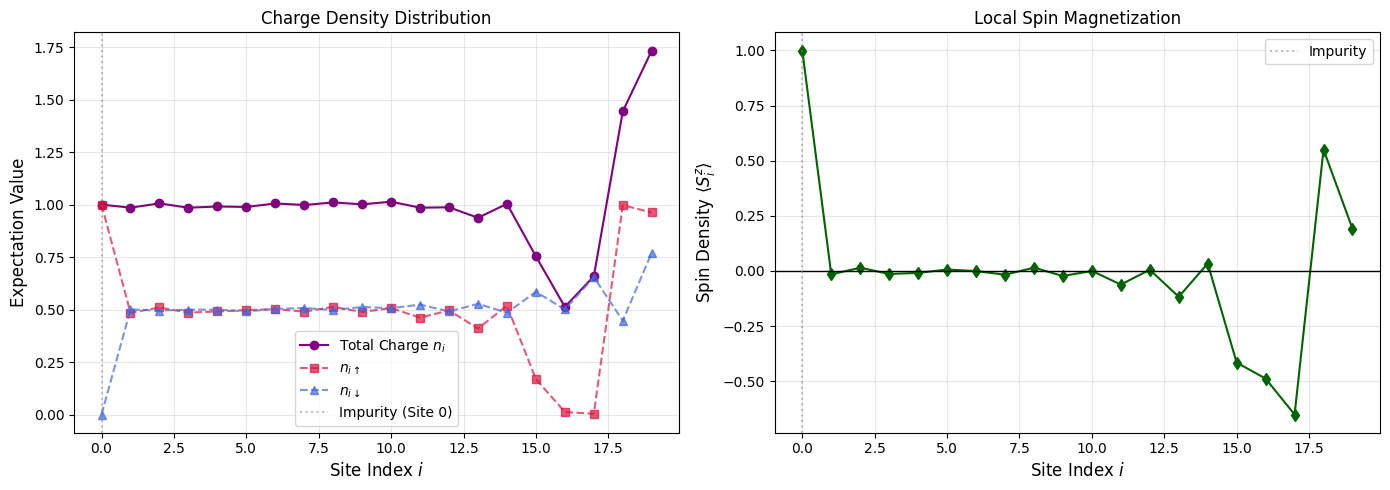

In [11]:
import numpy as np
import netket as nk
import netket.experimental as nkx  # 【新增】：导入实验性加速模块
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)")
print("=" * 70)

def compute_full_1rdm(vstate, n_sites):
    hilbert = vstate.hilbert
    rho_up = np.zeros((n_sites, n_sites), dtype=complex)
    rho_dn = np.zeros((n_sites, n_sites), dtype=complex)
    
    # 核心：锁定 MCMC 样本，保证 up 和 dn 的测量在同一批样本上进行，消除相对涨落
    _ = vstate.samples 
    print(f"已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...")

    for i in range(n_sites):
        for j in range(n_sites):
            # 1. 构造 Spin-Up 算符: c^\dagger_{i,\uparrow} c_{j,\uparrow}
            term_up = (((i, 1), (j, 0)),)
            op_up_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_up, dtype=float)
            # 【核心修改】：套上守恒外挂，切断无关希尔伯特空间的搜索
            op_up = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_up_raw)
            
            # 2. 构造 Spin-Down 算符: c^\dagger_{i,\downarrow} c_{j,\downarrow}
            term_dn = (((i + n_sites, 1), (j + n_sites, 0)),)
            op_dn_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_dn, dtype=float)
            # 【核心修改】：套上守恒外挂
            op_dn = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_dn_raw)
            
            # 计算期望值 (此时底层计算量极小)
            rho_up[i, j] = vstate.expect(op_up).mean
            rho_dn[i, j] = vstate.expect(op_dn).mean
            
        if (i + 1) % 4 == 0:
            print(f"进度: {i + 1} / {n_sites} 行已测算完成")
            
    return rho_up, rho_dn

# 执行测量 (假设 n_sites = 20)
n_sites = 20
rho_up, rho_dn = compute_full_1rdm(vstate_nj, n_sites)

# ==============================================================================
# 物理量提取：电荷与自旋分离
# ==============================================================================
# 1. 提取实空间对角占据数
n_up = np.real(np.diag(rho_up))
n_dn = np.real(np.diag(rho_dn))

# 2. 计算总电荷密度 (Charge Density): <n_{i\uparrow}> + <n_{i\downarrow}>
charge_density = n_up + n_dn

# 3. 计算局域自旋磁矩 (Spin Density / Local Magnetization): <n_{i\uparrow}> - <n_{i\downarrow}>
spin_density = n_up - n_dn

# ==============================================================================
# 物理图像可视化
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 电荷密度重分布 (Hubbard U 导致的排斥)
ax1.plot(range(n_sites), charge_density, 'o-', color='purple', label='Total Charge $n_i$')
ax1.plot(range(n_sites), n_up, 's--', color='crimson', alpha=0.7, label='$n_{i\\uparrow}$')
ax1.plot(range(n_sites), n_dn, '^--', color='royalblue', alpha=0.7, label='$n_{i\\downarrow}$')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity (Site 0)')
ax1.set_xlabel('Site Index $i$', fontsize=12)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Charge Density Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 图 2: 局域自旋极化 (Anderson/Kondo 物理的核心)
ax2.plot(range(n_sites), spin_density, 'd-', color='darkgreen', markersize=6)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity')
ax2.set_xlabel('Site Index $i$', fontsize=12)
ax2.set_ylabel('Spin Density $\\langle S^z_i \\rangle$', fontsize=12)
ax2.set_title('Local Spin Magnetization')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
import optax
import netket as nk

print("=" * 70)
print(">>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR")
print("=" * 70)

# ==============================================================================
# 1. 初始化模型与采样器
# ==============================================================================
# 这里的 hi, graph_sampler, SEED_MODEL_NJ, SEED_SAMPLER_NJ 请确保在前文已定义
model_nj = LogNeuralJastrowSlater(hi, hidden_units=8)
sa_nj = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler, spin_symmetric=True)

# 保持 16384 的高采样率，对于 Jastrow 来说毫无压力
vstate_nj = nk.vqs.MCState(
    sa_nj,
    model_nj,
    n_samples=2**12,          
    n_discard_per_chain=16,
    seed=SEED_MODEL_NJ,       
    sampler_seed=SEED_SAMPLER_NJ,
)

nj_p = vstate_nj.n_parameters
print(f" [NJ] Total Params: {nj_p} (参数量较小，QGT 矩阵极度健康)")

# ==============================================================================
# 2. 定制版外层优化器：Optax Adam
# ==============================================================================
lr_schedule_nj = optax.cosine_decay_schedule(
    init_value=0.02,   # 起步学习率，配合 SR 使用 0.02 是一个很稳的甜点位
    decay_steps=300, 
    alpha=0.01  
)

op_nj = optax.adam(
    learning_rate=lr_schedule_nj,
    b1=0.8,            # 【核心修改】：降低动量惯性，防止越过谷底后疯狂反弹 (Spikes)
    b2=0.999,          # 保持极高二阶矩，熨平 MCMC 的统计噪声
    eps=1e-8
)

# ==============================================================================
# 3. 驱动器：直接使用 VMC_SR 并开启物理加速
# ==============================================================================
gs_nj = nk.driver.VMC_SR(
    H, 
    op_nj, 
    variational_state=vstate_nj, 
    diag_shift=0.02,   
    mode="real"        # 【绝对核心】：砍掉无用的虚部计算，内存减半，单步速度飙升数倍！
)

# ==============================================================================
# 4. 运行优化与评估
# ==============================================================================
nj_log = nk.logging.RuntimeLog()
print("开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...")
gs_nj.run(n_iter=300, out=nj_log)

E_nj = vstate_nj.expect(H)
print("-" * 70)
print(f"Neural Jastrow-Slater optimized energy: {E_nj}")

# 如果你有精确基态能量 E_gs，可以取消下面的注释来计算相对误差
# err_nj = abs((E_nj.mean - E_gs) / E_gs)
# print(f"Relative error: {err_nj:.2e}")
print("=" * 70)

>>> [Cell 2] Jastrow 拟设：定制版 Adam + 开启实数加速的 VMC_SR
 [NJ] Total Params: 737 (参数量较小，QGT 矩阵极度健康)
Automatic SR implementation choice:  QGT
开始运行智能选择模式的 Jastrow 优化 (准备体验飞一般的速度)...


100%|██████████| 300/300 [05:10<00:00,  1.04s/it, Energy=-3.998491+0.000000j ± 0.000095 [σ²=2.9e-05, R̂=1.004]]


----------------------------------------------------------------------
Neural Jastrow-Slater optimized energy: -3.99864-0.00000j ± 0.00011 [σ²=4.4e-05, R̂=1.007]


>>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)
已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...
进度: 4 / 20 行已测算完成
进度: 8 / 20 行已测算完成
进度: 12 / 20 行已测算完成
进度: 16 / 20 行已测算完成
进度: 20 / 20 行已测算完成


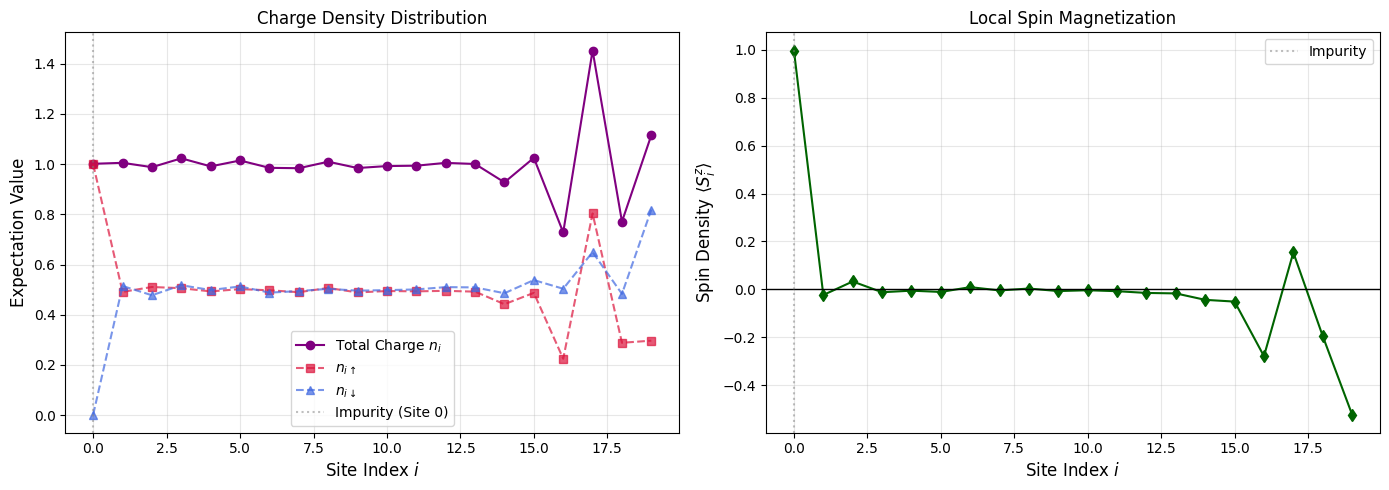

In [13]:
import numpy as np
import netket as nk
import netket.experimental as nkx  # 【新增】：导入实验性加速模块
import matplotlib.pyplot as plt

print("=" * 70)
print(">>> [测量模块] 强关联升级版：分离 Spin-Up 与 Spin-Down 1-RDM (开启守恒加速)")
print("=" * 70)

def compute_full_1rdm(vstate, n_sites):
    hilbert = vstate.hilbert
    rho_up = np.zeros((n_sites, n_sites), dtype=complex)
    rho_dn = np.zeros((n_sites, n_sites), dtype=complex)
    
    # 核心：锁定 MCMC 样本，保证 up 和 dn 的测量在同一批样本上进行，消除相对涨落
    _ = vstate.samples 
    print(f"已锁定 MCMC 样本，正在同时测算 Up 和 Down 轨道矩阵...")

    for i in range(n_sites):
        for j in range(n_sites):
            # 1. 构造 Spin-Up 算符: c^\dagger_{i,\uparrow} c_{j,\uparrow}
            term_up = (((i, 1), (j, 0)),)
            op_up_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_up, dtype=float)
            # 【核心修改】：套上守恒外挂，切断无关希尔伯特空间的搜索
            op_up = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_up_raw)
            
            # 2. 构造 Spin-Down 算符: c^\dagger_{i,\downarrow} c_{j,\downarrow}
            term_dn = (((i + n_sites, 1), (j + n_sites, 0)),)
            op_dn_raw = nk.operator.FermionOperator2nd(hilbert, terms=term_dn, dtype=float)
            # 【核心修改】：套上守恒外挂
            op_dn = nkx.operator.ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_dn_raw)
            
            # 计算期望值 (此时底层计算量极小)
            rho_up[i, j] = vstate.expect(op_up).mean
            rho_dn[i, j] = vstate.expect(op_dn).mean
            
        if (i + 1) % 4 == 0:
            print(f"进度: {i + 1} / {n_sites} 行已测算完成")
            
    return rho_up, rho_dn

# 执行测量 (假设 n_sites = 20)
n_sites = 20
rho_up, rho_dn = compute_full_1rdm(vstate_nj, n_sites)

# ==============================================================================
# 物理量提取：电荷与自旋分离
# ==============================================================================
# 1. 提取实空间对角占据数
n_up = np.real(np.diag(rho_up))
n_dn = np.real(np.diag(rho_dn))

# 2. 计算总电荷密度 (Charge Density): <n_{i\uparrow}> + <n_{i\downarrow}>
charge_density = n_up + n_dn

# 3. 计算局域自旋磁矩 (Spin Density / Local Magnetization): <n_{i\uparrow}> - <n_{i\downarrow}>
spin_density = n_up - n_dn

# ==============================================================================
# 物理图像可视化
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 图 1: 电荷密度重分布 (Hubbard U 导致的排斥)
ax1.plot(range(n_sites), charge_density, 'o-', color='purple', label='Total Charge $n_i$')
ax1.plot(range(n_sites), n_up, 's--', color='crimson', alpha=0.7, label='$n_{i\\uparrow}$')
ax1.plot(range(n_sites), n_dn, '^--', color='royalblue', alpha=0.7, label='$n_{i\\downarrow}$')
ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity (Site 0)')
ax1.set_xlabel('Site Index $i$', fontsize=12)
ax1.set_ylabel('Expectation Value', fontsize=12)
ax1.set_title('Charge Density Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 图 2: 局域自旋极化 (Anderson/Kondo 物理的核心)
ax2.plot(range(n_sites), spin_density, 'd-', color='darkgreen', markersize=6)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Impurity')
ax2.set_xlabel('Site Index $i$', fontsize=12)
ax2.set_ylabel('Spin Density $\\langle S^z_i \\rangle$', fontsize=12)
ax2.set_title('Local Spin Magnetization')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()